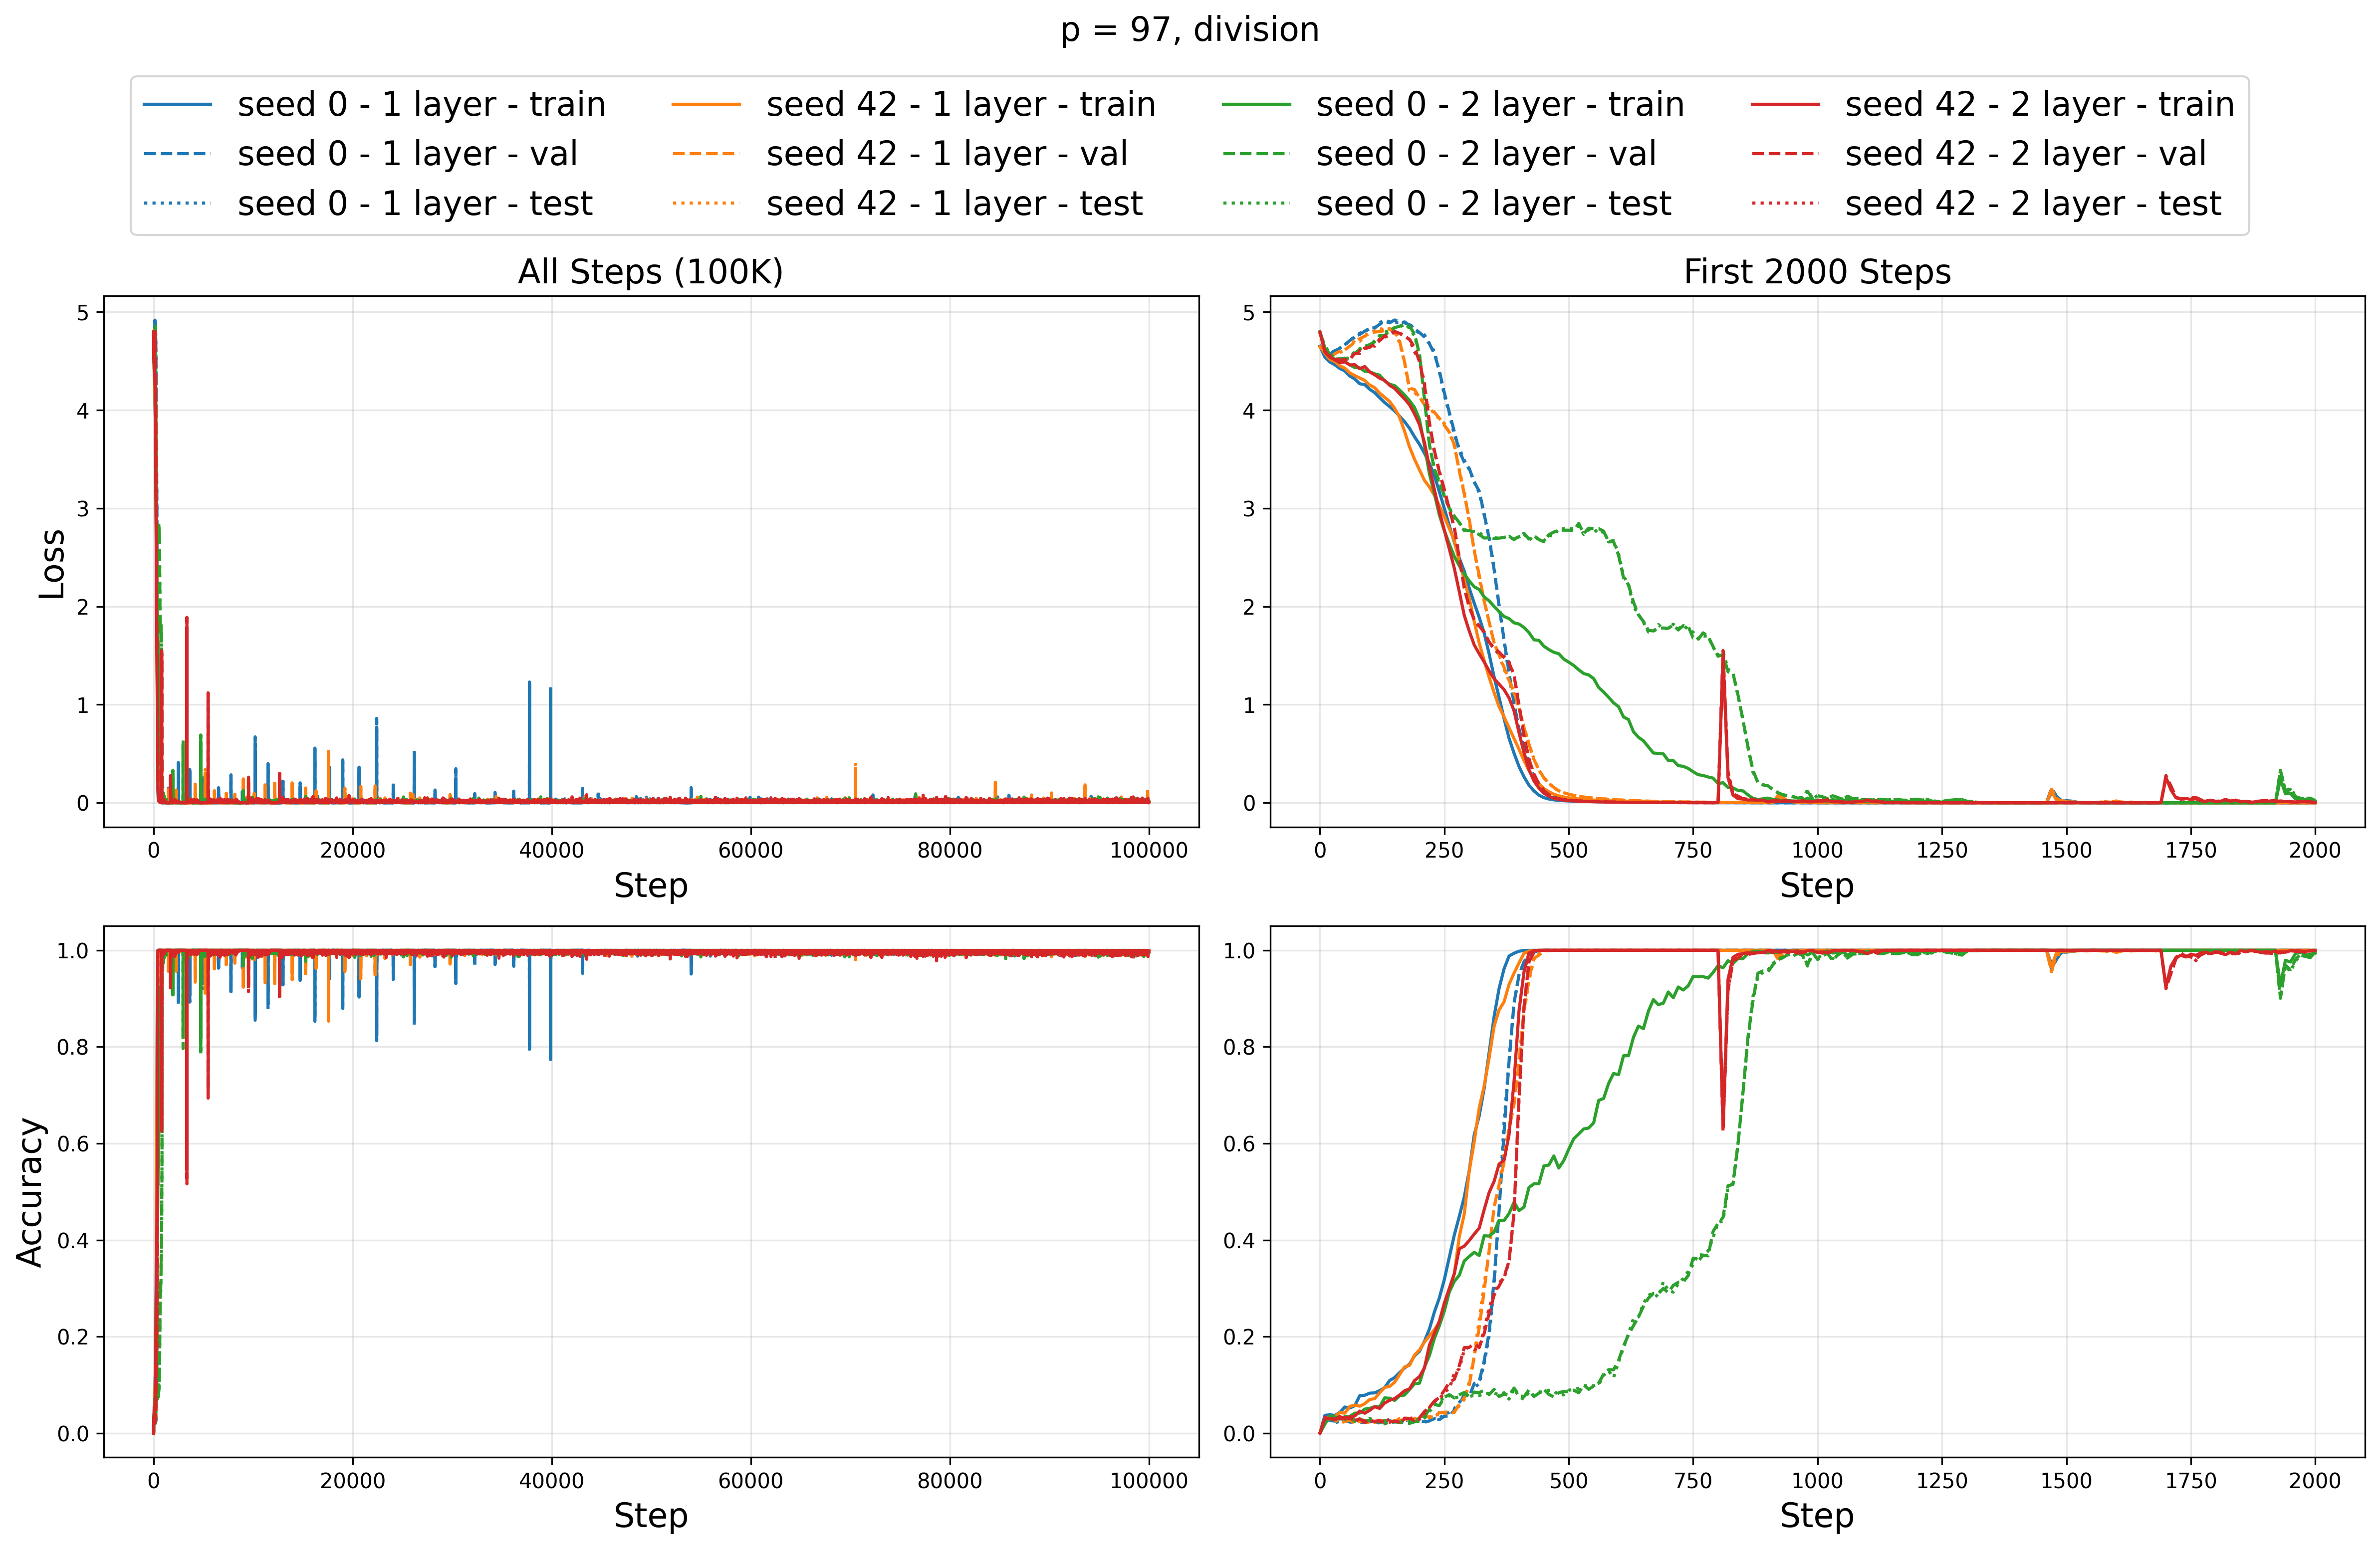

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

ROOT = Path("../runs")

RUN_CONFIGS = [
    {"seed": "0", "model": "1layer", "run_dir": ROOT / "p97_div_1layer_seed0"},
    {"seed": "42", "model": "1layer", "run_dir": ROOT / "p97_div_1layer_seed42"},
    {"seed": "0", "model": "2layer", "run_dir": ROOT / "p97_div_2layer_seed0"},
    {"seed": "42", "model": "2layer", "run_dir": ROOT / "p97_div_2layer_seed42"},
]

SPLITS = ["train_eval", "val", "test"]
SPLIT_LABELS = {"train_eval": "train", "val": "val", "test": "test"}
LINESTYLES = {"train_eval": "-", "val": "--", "test": ":"}
MAX_ZOOM_STEP = 2000


def read_scalar(event_path: Path, tag: str):
    ea = event_accumulator.EventAccumulator(
        str(event_path),
        size_guidance={event_accumulator.SCALARS: 0},
    )
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values


fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=300)
ax_loss_full, ax_loss_zoom = axes[0]
ax_acc_full, ax_acc_zoom = axes[1]

cmap = plt.get_cmap("tab10")
combo_colors = {
    (cfg["seed"], cfg["model"]): cmap(i % 10)
    for i, cfg in enumerate(RUN_CONFIGS)
}

for cfg in RUN_CONFIGS:
    seed = cfg["seed"]
    model = cfg["model"]
    run_dir = cfg["run_dir"]

    color = combo_colors[(seed, model)]

    event_file = next((run_dir / "tensorboard").glob("events.out.tfevents.*"))

    for split in SPLITS:
        loss_tag = f"loss/{split}"
        acc_tag = f"acc/{split}"

        loss_steps, loss_vals = read_scalar(event_file, loss_tag)
        acc_steps, acc_vals = read_scalar(event_file, acc_tag)

        model_label = "1 layer" if model == "1layer" else "2 layer"
        label = f"seed {seed} - {model_label} - {SPLIT_LABELS[split]}"
        linestyle = LINESTYLES[split]

        ax_loss_full.plot(loss_steps, loss_vals, color=color, linestyle=linestyle, label=label)
        ax_acc_full.plot(acc_steps, acc_vals, color=color, linestyle=linestyle, label=label)

        loss_zoom = [(s, v) for s, v in zip(loss_steps, loss_vals) if s <= MAX_ZOOM_STEP]
        acc_zoom = [(s, v) for s, v in zip(acc_steps, acc_vals) if s <= MAX_ZOOM_STEP]

        if loss_zoom:
            l_steps, l_vals = zip(*loss_zoom)
            ax_loss_zoom.plot(l_steps, l_vals, color=color, linestyle=linestyle, label=label)

        if acc_zoom:
            a_steps, a_vals = zip(*acc_zoom)
            ax_acc_zoom.plot(a_steps, a_vals, color=color, linestyle=linestyle, label=label)

# formatting
for ax in [ax_loss_full, ax_loss_zoom, ax_acc_full, ax_acc_zoom]:
    ax.set_xlabel("Step", fontsize=16)
    ax.grid(alpha=0.3)

ax_loss_full.set_title("All Steps (100K)", fontsize=16)
ax_loss_zoom.set_title(f"First {MAX_ZOOM_STEP} Steps", fontsize=16)
ax_loss_full.set_ylabel("Loss", fontsize=16)
ax_acc_full.set_ylabel("Accuracy", fontsize=16)

handles, labels = ax_loss_full.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=16, bbox_to_anchor=(0.5, 1.00))
fig.suptitle("p = 97, division", fontsize=16, y=1.03)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
